In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3



In [2]:
conn = sqlite3.connect('customer_churn.db')

sql_query ="""
          SELECT name
          FROM sqlite_master
          WHERE type='table'
"""


tables= pd.read_sql(sql_query, conn)

#create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM { table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()
    


Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
#Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

#close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [4]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [5]:
# 2 data cleaning

In [6]:
#df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [7]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [8]:
# a. drop columns - interest and pincode
# b. rename column - name
# c. change data type - dob
# d. fix missing values - country
# e. data standardization - gender

In [9]:
df_db_customer. rename(columns = {'name' : 'customer_name'}, inplace= True)

In [10]:
# a. drop columns - interest and pincode
#df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
#for whole column axis=1 and for rows axis=0
df_db_customer.drop(columns=['interests' , 'pincode'],inplace= True)

In [11]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   customer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


In [12]:
# c. change data type - dob and change rest to object dtype
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
df_db_customer['customerid'] = df_db_customer['customerid'].astype(object)
df_db_customer['customer_name'] = df_db_customer['customer_name'].astype(object)
df_db_customer['country'] = df_db_customer['country'].astype(object)
df_db_customer['state'] = df_db_customer['state'].astype(object)
df_db_customer['gender'] = df_db_customer['gender'].astype(object)

In [13]:
# e. data standardization - gender
#df_db_customer['gender'].unique()
df_db_customer['gender']= df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [14]:
# d. fix missing values - country
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [15]:
#df_db_customer['country'].fillna()
df_db_customer[['country','state']]
# country and state - unique value pair
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [16]:
df_db_customer[['country','state']]


,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [17]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [18]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [19]:
#change data type of columns
date_col = ['subscription_start_date','renewal_date', 'cancellation_date']
df_db_subscription[date_col]= df_db_subscription[date_col].apply(pd.to_datetime)
typ_col= ['customerid','subscription_type','plan_type','contract_type','cancellation_reason']
df_db_subscription[typ_col]=df_db_subscription[typ_col].astype(object)

In [20]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [21]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [22]:
df_db_support.drop(columns=['col_1','comment'],inplace=True)

In [23]:
df_db_support['complaint_date']= pd.to_datetime(df_db_support['complaint_date'])  

In [24]:
df_db_support[['customerid','escalations']] = df_db_support[['customerid','escalations']].astype(object)



In [25]:
#3. Feature Egineering  and Data Analysis

In [26]:
#create a new col using existing col- churn flag
df_db_subscription['churn flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [27]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [28]:
df=(df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))


In [29]:
df_db_subscription.shape

(21, 12)

In [30]:
df.shape

(23, 20)

In [31]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [32]:
df_db_subscription['customerid'].nunique()

21

In [33]:
df_db_customer['customerid'].nunique()

21

In [34]:
df_db_support['customerid'].nunique()

7

In [35]:
df_db_support['customerid'].size

9

In [36]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [37]:
#fix the multiple customer records in support database to get unique records only and avoid multiple copy of records
df_db_support['complaint_count']= df_db_support.groupby('customerid')['customerid'].transform('count')

In [38]:
df_db_support= df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [39]:

df=(df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left'))


In [40]:
df.shape

(21, 21)

In [41]:
#df.to_csv('exported_churn_data.csv', index= False)

In [42]:
#Data Analysis

In [43]:
# 1.Churn Rate

In [44]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [45]:
churn_rate= df['churn flag'].mean()*100
print("Churn rate =", round(churn_rate,2), "%") 

Churn rate = 28.57 %


In [46]:
#2.Retention Rate
retention_rate = 100- churn_rate
print("Retention rate =", round(retention_rate,2), "%") 

Retention rate = 71.43 %


In [47]:
#3. churn by plan type
churn_by_plan= df.groupby('plan_type')['churn flag'].mean().mul(100).round(2).reset_index(name= 'churn_rate_pct')
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [48]:
#4. a. Churn by state + sum(revenue) & count of users ---- homework
# 4.b. Churn by subscription type + sum(revenue) & count of users ---- homework



In [49]:
#churn_by_state = (df.groupby('state').agg(['churn flag'].mean().mul(100).round(2),
 #   total_revenue=('revenue', 'sum'),
  #  user_count=('customer_id', 'count')
#).reset_index(name= 'churn_rate_pct'))
#print(churn_by_state)


In [50]:
#5. ARPU- Avg revenue per user


In [51]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [52]:
arpu= df['monthly_charges'].mean()
print('ARPU =', round(arpu,2))

ARPU = 18.85


In [53]:
#homework - calculate customer age

In [54]:
#6. avg customer tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()
df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date']- df['subscription_start_date']).dt.days,
    (today-df['subscription_start_date']).dt.days
)
df.head()
avg_tenure= df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)
# different result as given in video

Avg Tenure (Days) =  1516 0


In [55]:
# 7. revenue at risk - revenue lost from churned users 
revenue_at_risk = df.loc[df ['churn flag']==1, 'monthly_charges'].sum()
print("Revnue at risk (Rs 'k') = ", revenue_at_risk)

Revnue at risk (Rs 'k') =  73.94


In [56]:
#8. Escalation Rate 
escalation_rate = (df['escalations'] =='Y').mean()*100
print("Escalation Rate = ", round(escalation_rate,2), "%")

Escalation Rate =  19.05 %


In [57]:
# 9. average complaint per user 
avg_complaints = df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg complaint per user = ", round(avg_complaints,2))

Avg complaint per user =  0.43


In [58]:
#10. correlation escalation vs  churn
df['escalations']= np.where(df['escalations']== 'Y',1,0) # encoding string to int type
corr_df= df[['escalations', 'churn flag']].dropna()
correlation = corr_df['escalations'].corr(df['churn flag'])
print("correlation between escalation vs churn is = ", round(correlation,2))

correlation between escalation vs churn is =  0.77


In [59]:
# 11. churn risk - create a column using existing column
#df['churn_score'].head()
conditions = [
    (df['churn_score'] <50),
    (df['churn_score'] >=50)& (df['churn_score'] <70),
    (df['churn_score'] >70),
]
choices= ['low', 'med', 'high']
df['churn_risk'] = np.select(conditions, choices, default='unkown')



In [60]:
#df[['churn_risk','churn_score']].tail()

In [61]:
# Visualisation using Matplotlib

In [62]:
df_visual = df.copy()

In [63]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1977.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1362.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2652.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [64]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

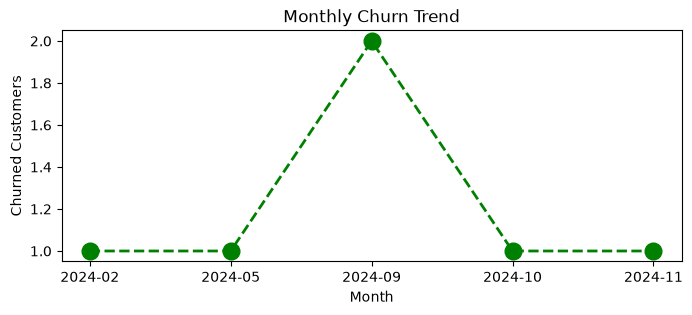

In [65]:
# 1.Monthly churn trend(time series KPI)
df_visual['cancellation_month']= df_visual['cancellation_date'].dt.to_period('M')
churn_trend = df_visual[df_visual['churn flag']==1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

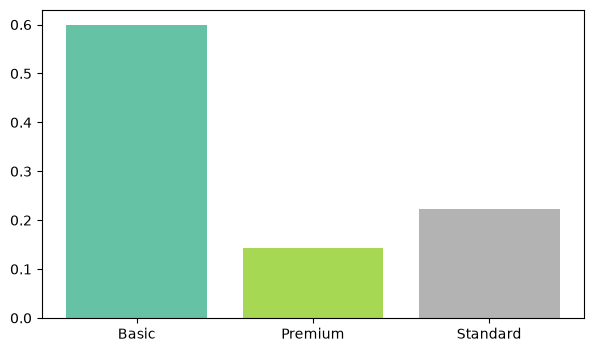

In [66]:
# 2. Churn by plan type
churn_plan= df_visual.groupby('plan_type')['churn flag'].mean()
#colors=['yellow','purple','red']
colors= plt.cm.Set2(np.linspace(0,1, len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index, churn_plan.values, color=colors)
plt.show()


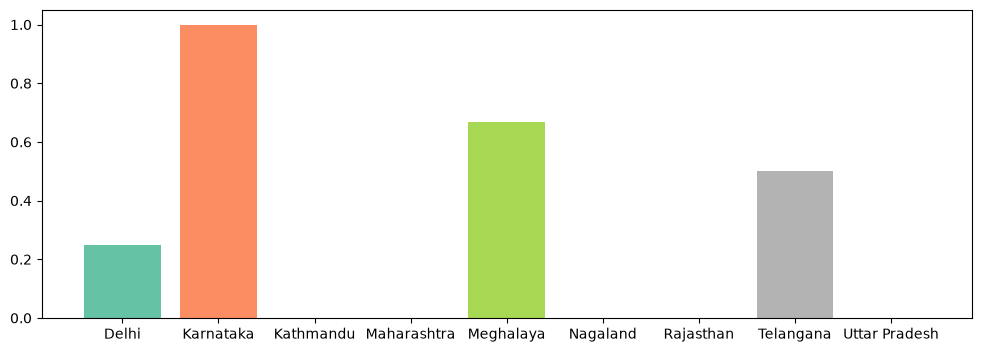

In [67]:
#3. churn by states
churn_plan= df_visual.groupby('state')['churn flag'].mean()
#colors=['yellow','purple','red']
colors= plt.cm.Set2(np.linspace(0,1, len(churn_plan)))
plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color=colors)
plt.show()



In [68]:
#Visualisation using seaborn


In [69]:
#encoding- convert str to numeric so that we can find corr between features 
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [70]:
df_visual[['plan_type', 'contract_type', 'churn_score','churn flag', 'escalations','churn_risk']].head()

,plan_type,contract_type,churn_score,churn flag,escalations,churn_risk
0,Standard,Annual,12,0,0,low
1,Premium,Annual,91,1,1,high
2,Basic,Monthly,34,0,0,low
3,Premium,Annual,8,0,0,low
4,Standard,Monthly,88,1,1,high


In [71]:
#df_encoded.head()

In [72]:
import warnings
warnings.filterwarnings('ignore')

In [73]:
#incorrect method of encoding - as numbers are not assinged based on priority (cat codes)
df_encoded= df_visual[['plan_type', 'contract_type', 'churn_score','churn flag', 'escalations','churn_risk']]
categorial_cols= ['plan_type','contract_type','churn_risk']

for col in categorial_cols:
    df_encoded[col]= df_encoded[col].astype('category').cat.codes

<Axes: >

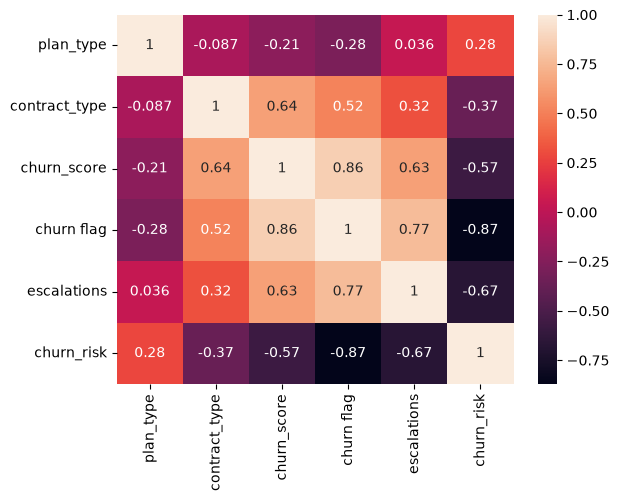

In [74]:
#Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

In [75]:
df_visual['plan_type'].unique()


array(['Standard', 'Premium', 'Basic'], dtype=object)

In [76]:
df_visual['contract_type'].unique()


array(['Annual', 'Monthly'], dtype=object)

In [77]:
df_visual['churn_risk'].unique()


<StringArray>
['low', 'high', 'med']
Length: 3, dtype: str

In [78]:
#correct method of encoding - as numbers are not assinged based on priority
df_encoded= df_visual[['plan_type', 'contract_type', 'churn_score','churn flag', 'escalations','churn_risk']]
order_mappings= {
    'plan_type':['Basic', 'Standard','Premium'], 
    'contract_type':['Monthly','Annual'],
    'churn_risk':['low', 'med','high']
}


for col, order in order_mappings.items():
    df_encoded[col]= pd.Categorical(df_encoded[col].astype('category'),categories=order,ordered=True).codes


In [79]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn flag,escalations,churn_risk
0,1,1,12,0,0,0
1,2,1,91,1,1,2
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,1,2


<Axes: >

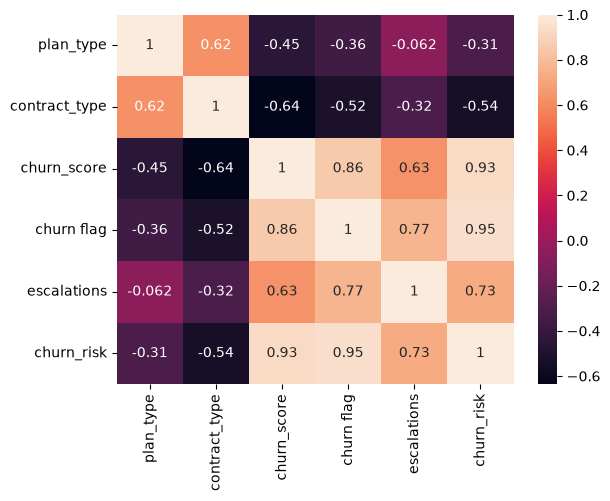

In [80]:
#Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)

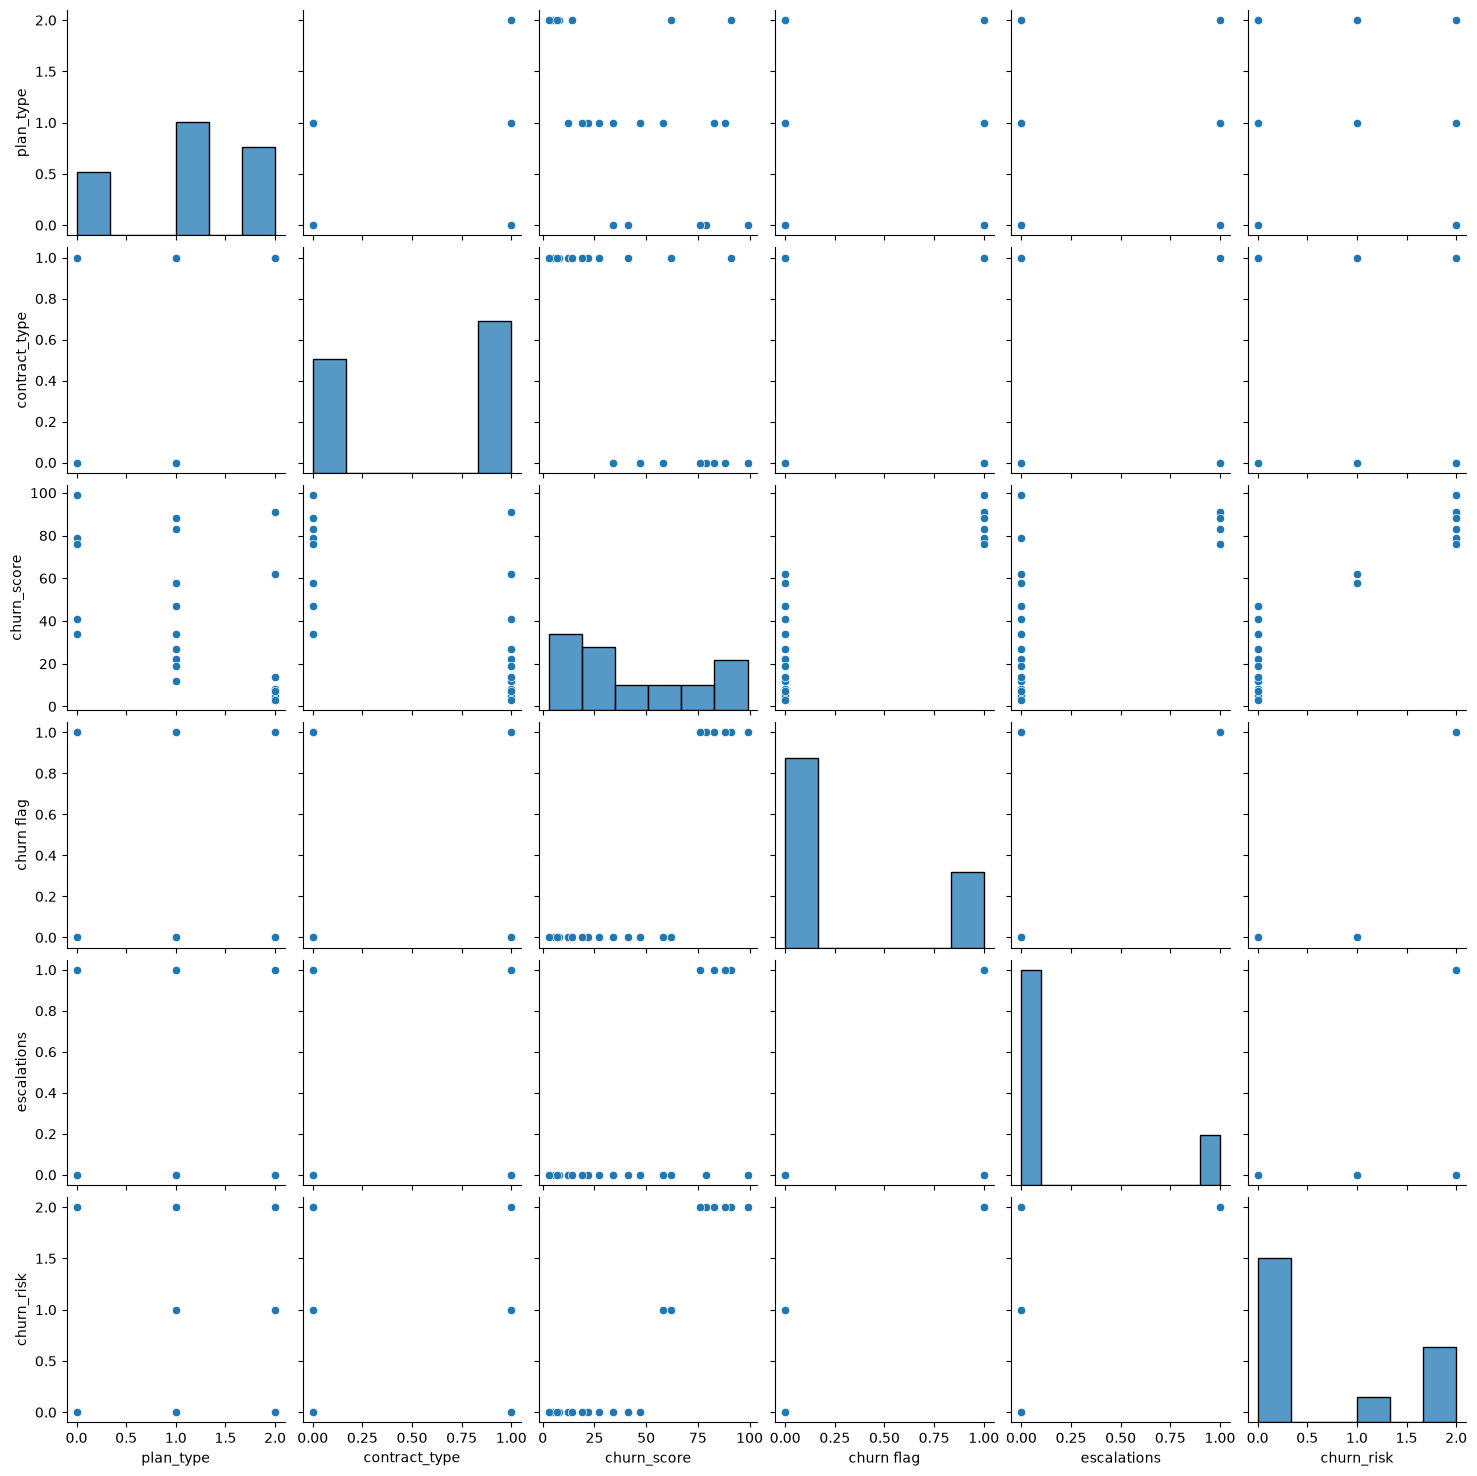

In [81]:
#pairplot - relationship in a dataset
sns.pairplot(df_encoded)

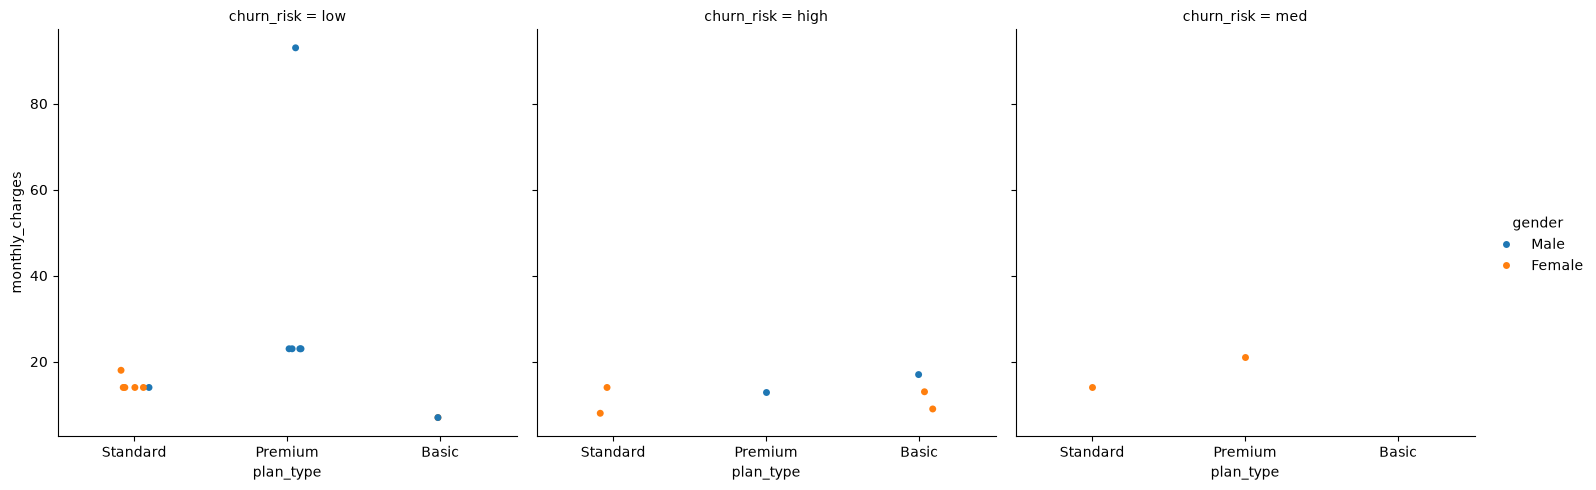

In [82]:
# catplt/Facegrid plot - multi-dim comparison
sns.catplot(data= df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [83]:
pd.pivot_table(
    df_visual,
    index='plan_type' , 
    values=['monthly_charges' , 'customerid', 'churn flag'],
    aggfunc ={
        'monthly_charges' : 'sum',
        'customerid' : 'nunique' ,
        'churn flag' : 'mean'
    }
)

,churn flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [84]:
#conn.close()